# 02. 개체 단위 불균형 및 수명 주기 분석 (Entity-Level Imbalance & Lifecycle Analysis)

이 노트북은 정제된 Seagate ST4000DM000 디스크 데이터셋(`ST4000DM000_cleaned_2.parquet`)을 대상으로 **개체 단위(Entity-level) 클래스 불균형**과 **디스크 수명 주기(Lifecycle Length)**, 그리고 **시계열 공백에 따른 청크 분할(Chunking)** 특성을 전문적이고 다각적인 통계로 분석합니다.

### 주요 분석 목표:
1. **계층별 불균형 분석 (Hierarchical Class Imbalance)**:
   - 관측치 레벨(Row-level), 물리 디스크 레벨(Physical Disk-level / Base Serial), 청크 레벨(Chunked Serial-level / Serial Number) 각각의 클래스 불균형 비율을 산출하고 비교 분석합니다.
2. **디스크 수명 주기 분석 (Lifecycle Length & Censoring)**:
   - 정상 디스크와 고장 디스크 간의 모니터링 수명(일수) 분포 차이를 규명하고, 생존 분석(Survival Analysis) 관점의 좌측/우측 절단(Left/Right Censoring) 및 좀비/조기 이탈 현상을 탐색합니다.
3. **청크 분할 및 시계열 연속성 분석 (Chunking & Timeline Gaps)**:
   - 2단계 전처리에서 적용된 '2일 이상 공백 시 분할' 정책으로 인해 물리 디스크가 청크로 쪼개지는 빈도와 그 차이를 분석합니다.
4. **머신러닝 모델링을 위한 개체 단위 분할(Group Split) 및 샘플링 전략 제언**:
   - 디스크 개체 단위 누수(Data Leakage) 차단 필요성과 클래스 불균형 해결을 위한 샘플링 방안을 제시합니다.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# 한글 폰트 설정 (Windows 환경 대응)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 시각화용 프리미엄 컬러 팔레트
PRIMARY_COLOR = "#2b5c8f"  # Slate Blue (정상/안정군)
ACCENT_COLOR = "#e05a47"   # Coral Red (고장/위험군)
NEUTRAL_DARK = "#2c3e50"

# 입력 데이터 경로 설정 (상대 경로)
parquet_path = "../../data2/01_cleaned/ST4000DM000_cleaned_2.parquet"

print(f"입력 데이터 경로: {Path(parquet_path).resolve()}")
if os.path.exists(parquet_path):
    print("✅ 데이터 파일이 존재하며 연결할 준비가 되었습니다.")
else:
    print("❌ 데이터 파일이 없습니다. 경로를 확인해 주세요.")

입력 데이터 경로: C:\Workspace\06_ML_projdect\26_1_COIN\data2\01_cleaned\ST4000DM000_cleaned_2.parquet
✅ 데이터 파일이 존재하며 연결할 준비가 되었습니다.


## 1. DuckDB를 활용한 데이터 로드 및 스키마 검증

약 7,700만 건에 달하는 대용량 시계열 Parquet 파일을 효율적이고 빠르게 분석하기 위해 전역 DuckDB 세션을 연결하여 분석 쿼리를 수행합니다.

In [2]:
con = duckdb.connect()

# 1. 데이터셋 전체 스키마 기술
schema_df = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{parquet_path}')").df()

# 2. 총 레코드 및 컬럼 수 계산
total_rows = con.execute(f"SELECT COUNT(*) FROM read_parquet('{parquet_path}')").fetchone()[0]
num_cols = len(schema_df)

print(f"--- 데이터셋 요약 ---")
print(f"총 관측치 수 (Rows): {total_rows:,}건")
print(f"총 컬럼 수 (Columns): {num_cols}개")

print("\n[컬럼별 데이터 타입 요약]")
print(schema_df[['column_name', 'column_type']].to_string(index=False))

--- 데이터셋 요약 ---
총 관측치 수 (Rows): 77,362,978건
총 컬럼 수 (Columns): 27개

[컬럼별 데이터 타입 요약]
     column_name column_type
   serial_number     VARCHAR
            date        DATE
         failure      BIGINT
     smart_3_raw      BIGINT
     smart_4_raw      BIGINT
     smart_5_raw      BIGINT
     smart_9_raw      BIGINT
    smart_10_raw      BIGINT
   smart_183_raw      BIGINT
   smart_184_raw      BIGINT
   smart_187_raw      BIGINT
   smart_189_raw      BIGINT
   smart_191_raw      BIGINT
   smart_192_raw      BIGINT
   smart_193_raw      BIGINT
   smart_197_raw      BIGINT
   smart_198_raw      BIGINT
   smart_199_raw      BIGINT
   smart_241_raw      BIGINT
   smart_242_raw      BIGINT
     Total_Reads      BIGINT
seek_error_count      BIGINT
     total_seeks      BIGINT
   Timeout_Total      BIGINT
      Timeout_5s      BIGINT
   smart_190_raw      BIGINT
   smart_194_raw      BIGINT


## 2. 계층별 불균형 분석 (Hierarchical Class Imbalance)

이상 탐지(Anomaly Detection) 및 디스크 고장 예측(PdM) 분석에서 가장 핵심이 되는 요소는 **클래스 불균형(Class Imbalance)**입니다. 하드디스크 데이터는 다음 3가지 계층 구조를 갖습니다:

1. **관측치 레벨 (Row-level)**: 하루 단위 수집된 SMART 레코드 행들의 불균형. 고장 시점 직전 30일(D-30 ~ D-0)에만 고장 라벨(`failure=1`)을 부여하므로 극단적인 불균형이 발생합니다.
2. **물리 디스크 레벨 (Physical Disk-level / Base Serial)**: 실제 개별 하드디스크 장비 기준의 불균형. 평생 한 번이라도 고장난 디스크 수 대비 건강하게 작동/폐기된 디스크의 비율입니다. (`regexp_replace(serial_number, '_[0-9]+$', '')`로 식별)
3. **청크 레벨 (Chunked Serial-level / Serial Number)**: 시계열 수집 중 2일 이상 공백으로 인해 독립된 시계열 청크로 분할 배정된 시리얼 단위의 불균형입니다.

In [3]:
print("🚀 계층별 클래스 불균형 통계 계산 중...")

# 1. Row-level
row_stats = con.execute(f"""
    SELECT 
        COUNT(*) as total,
        SUM(CASE WHEN failure = 1 THEN 1 ELSE 0 END) as failed,
        SUM(CASE WHEN failure = 0 THEN 1 ELSE 0 END) as normal
    FROM read_parquet('{parquet_path}')
""").fetchone()

# 2. Base Serial (물리 디스크)
base_serial_stats = con.execute(f"""
    WITH BaseMax AS (
        SELECT 
            regexp_replace(serial_number, '_[0-9]+$', '') as base_serial,
            MAX(failure) as max_fail
        FROM read_parquet('{parquet_path}')
        GROUP BY 1
    )
    SELECT 
        COUNT(*) as total,
        SUM(CASE WHEN max_fail = 1 THEN 1 ELSE 0 END) as failed,
        SUM(CASE WHEN max_fail = 0 THEN 1 ELSE 0 END) as normal
    FROM BaseMax
""").fetchone()

# 3. Serial Number (청크)
serial_stats = con.execute(f"""
    WITH SerialMax AS (
        SELECT 
            serial_number,
            MAX(failure) as max_fail
        FROM read_parquet('{parquet_path}')
        GROUP BY 1
    )
    SELECT 
        COUNT(*) as total,
        SUM(CASE WHEN max_fail = 1 THEN 1 ELSE 0 END) as failed,
        SUM(CASE WHEN max_fail = 0 THEN 1 ELSE 0 END) as normal
    FROM SerialMax
""").fetchone()

print("\n=== [1] 관측치 레벨 (Row-level) 불균형 ===")
print(f"  - 전체 관측 행 수: {row_stats[0]:,}건")
print(f"  - 고장 라벨 행 수: {row_stats[1]:,}건 ({row_stats[1]/row_stats[0]*100:.4f}%) - [Minority]")
print(f"  - 정상 라벨 행 수: {row_stats[2]:,}건 ({row_stats[2]/row_stats[0]*100:.4f}%) - [Majority]")
print(f"  - 불균형 비율 (정상:고장): {row_stats[2]/row_stats[1]:.1f} : 1")

print("\n=== [2] 물리 디스크 레벨 (Physical Disk-level) 불균형 (Base Serial) ===")
print(f"  - 전체 물리 디스크 수: {base_serial_stats[0]:,}개")
print(f"  - 고장 발생 디스크 수: {base_serial_stats[1]:,}개 ({base_serial_stats[1]/base_serial_stats[0]*100:.2f}%) - [Minority]")
print(f"  - 평생 정상 디스크 수: {base_serial_stats[2]:,}개 ({base_serial_stats[2]/base_serial_stats[0]*100:.2f}%) - [Majority]")
print(f"  - 불균형 비율 (정상:고장): {base_serial_stats[2]/base_serial_stats[1]:.1f} : 1")

print("\n=== [3] 청크 레벨 (Chunked Serial-level) 불균형 (Serial Number) ===")
print(f"  - 전체 시계열 청크 수: {serial_stats[0]:,}개")
print(f"  - 고장 포함 청크 수: {serial_stats[1]:,}개 ({serial_stats[1]/serial_stats[0]*100:.2f}%) - [Minority]")
print(f"  - 고장 미포함 청크 수: {serial_stats[2]:,}개 ({serial_stats[2]/serial_stats[0]*100:.2f}%) - [Majority]")
print(f"  - 불균형 비율 (정상:고장): {serial_stats[2]/serial_stats[1]:.1f} : 1")

🚀 계층별 클래스 불균형 통계 계산 중...



=== [1] 관측치 레벨 (Row-level) 불균형 ===
  - 전체 관측 행 수: 77,362,978건
  - 고장 라벨 행 수: 173,314건 (0.2240%) - [Minority]
  - 정상 라벨 행 수: 77,189,664건 (99.7760%) - [Majority]
  - 불균형 비율 (정상:고장): 445.4 : 1

=== [2] 물리 디스크 레벨 (Physical Disk-level) 불균형 (Base Serial) ===
  - 전체 물리 디스크 수: 36,931개
  - 고장 발생 디스크 수: 5,701개 (15.44%) - [Minority]
  - 평생 정상 디스크 수: 31,230개 (84.56%) - [Majority]
  - 불균형 비율 (정상:고장): 5.5 : 1

=== [3] 청크 레벨 (Chunked Serial-level) 불균형 (Serial Number) ===
  - 전체 시계열 청크 수: 84,208개
  - 고장 포함 청크 수: 5,882개 (6.99%) - [Minority]
  - 고장 미포함 청크 수: 78,326개 (93.01%) - [Majority]
  - 불균형 비율 (정상:고장): 13.3 : 1


### 시각화: 관측치 레벨 vs 물리 디스크 레벨 클래스 분포 비교

두 수준의 불균형 정도 차이는 **수십 배**에 달합니다. 
- 관측치 레벨(Row)에서는 고장 데이터가 단 **0.22%**에 불과하지만,
- 물리 디스크 레벨(Base Serial)에서는 고장 디스크 비중이 **15.4%**로 비교적 넉넉히 수집되어 있습니다.
- 이는 고장 디스크 1개체당 수천 일 이상의 오랜 정상 모니터링 시계열이 누적되면서 발생하는 **시간 차원의 극단적 희석(Temporal Dilution)** 때문입니다.

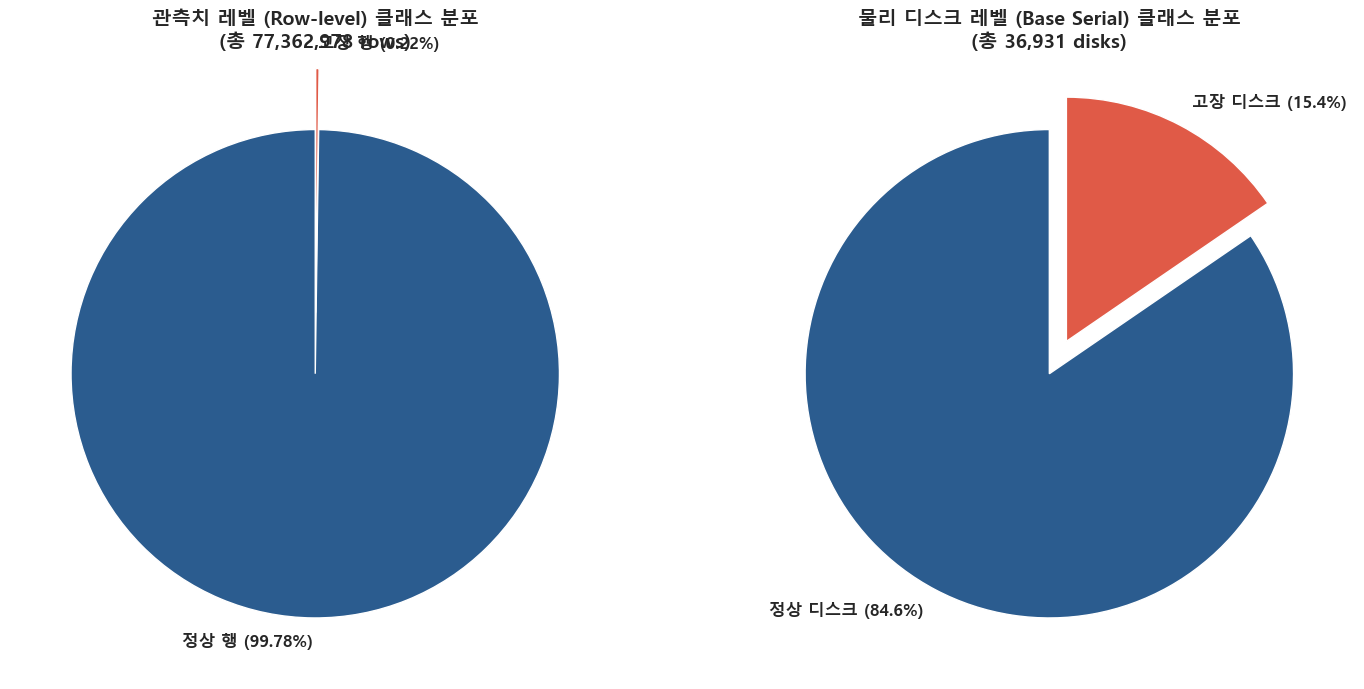

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# 1. Row-level Pie Chart
axes[0].pie(
    [row_stats[2], row_stats[1]], 
    labels=['정상 행 (99.78%)', '고장 행 (0.22%)'], 
    autopct='', 
    startangle=90, 
    colors=[PRIMARY_COLOR, ACCENT_COLOR],
    explode=[0, 0.25],
    textprops={'fontsize': 12, 'weight': 'bold'}
)
axes[0].set_title("관측치 레벨 (Row-level) 클래스 분포\n(총 77,362,978 rows)", fontsize=14, weight='bold', pad=15)

# 2. Base Serial Pie Chart
axes[1].pie(
    [base_serial_stats[2], base_serial_stats[1]], 
    labels=[f'정상 디스크 ({base_serial_stats[2]/base_serial_stats[0]*100:.1f}%)', f'고장 디스크 ({base_serial_stats[1]/base_serial_stats[0]*100:.1f}%)'], 
    autopct='', 
    startangle=90, 
    colors=[PRIMARY_COLOR, ACCENT_COLOR],
    explode=[0, 0.15],
    textprops={'fontsize': 12, 'weight': 'bold'}
)
axes[1].set_title(f"물리 디스크 레벨 (Base Serial) 클래스 분포\n(총 {base_serial_stats[0]:,} disks)", fontsize=14, weight='bold', pad=15)

plt.tight_layout()
plt.show()

## 3. 디스크 수명 주기 분석 (Lifecycle Length & Censoring Analysis)

각 물리 디스크(Base Serial)가 데이터셋 내에 머무른 기간(즉, 수집된 시계열 일수)을 **수명 주기(Lifecycle Length)**로 정의합니다.
- **고장 디스크 (Failed Disks)**: 실제로 고장이 일어나 모니터링이 중단된 디스크. 수명 주기가 고장으로 인해 조기 종결되는 경향이 있습니다.
- **정상 디스크 (Healthy Disks)**: 데이터 수집 기간 종료(우측 절단, Right Censoring)까지 고장나지 않고 살아남은 생존 개체들입니다.

두 군집의 수명 주기 통계를 상세히 대조하여 장비 수명 분포의 차이를 분석합니다.

In [5]:
print("🚀 물리 디스크 수명 주기 분석 쿼리 수행 중...")

lifecycle_query = f"""
    SELECT 
        regexp_replace(serial_number, '_[0-9]+$', '') as base_serial,
        CAST(MAX(failure) AS BIGINT) as is_failed,
        COUNT(*) as lifecycle_days
    FROM read_parquet('{parquet_path}')
    GROUP BY 1
"""
lifecycle_df = con.execute(lifecycle_query).df()

# 분위수 및 요약 정보 출력
summary = lifecycle_df.groupby('is_failed')['lifecycle_days'].describe()
summary.index = ['정상 디스크 (is_failed=0)', '고장 디스크 (is_failed=1)']

print("\n--- [물리 디스크 수명 주기 요약 통계 (일 단위)] ---")
print(summary.round(2).to_string())

# 중위수 수명 비교 논평
med_healthy = lifecycle_df[lifecycle_df['is_failed'] == 0]['lifecycle_days'].median()
med_failed = lifecycle_df[lifecycle_df['is_failed'] == 1]['lifecycle_days'].median()
print(f"\n💡 정상 디스크의 중위 수명: {med_healthy:,}일 (~{med_healthy/365:.1f}년)")
print(f"💡 고장 디스크의 중위 수명: {med_failed:,}일 (~{med_failed/365:.1f}년)")
print(f"💡 고장 디스크는 정상 디스크 대비 중위수 수명이 약 {med_healthy - med_failed:.0f}일 정도로 매우 조기에 퇴역합니다.")

🚀 물리 디스크 수명 주기 분석 쿼리 수행 중...



--- [물리 디스크 수명 주기 요약 통계 (일 단위)] ---
                        count     mean     std  min     25%     50%     75%     max
정상 디스크 (is_failed=0)  31230.0  2243.21  822.56  4.0  1477.0  2867.0  2945.0  3171.0
고장 디스크 (is_failed=1)   5701.0  1281.80  875.83  1.0   546.0  1099.0  2075.0  3116.0

💡 정상 디스크의 중위 수명: 2,867.0일 (~7.9년)
💡 고장 디스크의 중위 수명: 1,099.0일 (~3.0년)
💡 고장 디스크는 정상 디스크 대비 중위수 수명이 약 1768일 정도로 매우 조기에 퇴역합니다.


### 시각화: 수명 주기 분포 비교 (KDE & Histogram)

정상 디스크와 고장 디스크의 수명 주기 밀도 분포(Density Distribution)를 시각화합니다.
- **정상 디스크 (Blue)**: 수명 주기 분포가 2,500일~4,000일 부근에 고밀도로 쏠려 있습니다. 이는 장시간 가동 중인 생존자(Censored)들이 대다수임을 뜻합니다.
- **고장 디스크 (Orange)**: 수명이 500일~1,500일 부근에 넓게 펴져 있으며 상대적으로 훨씬 짧은 시점에 조기 탈락하는 형태를 띱니다.

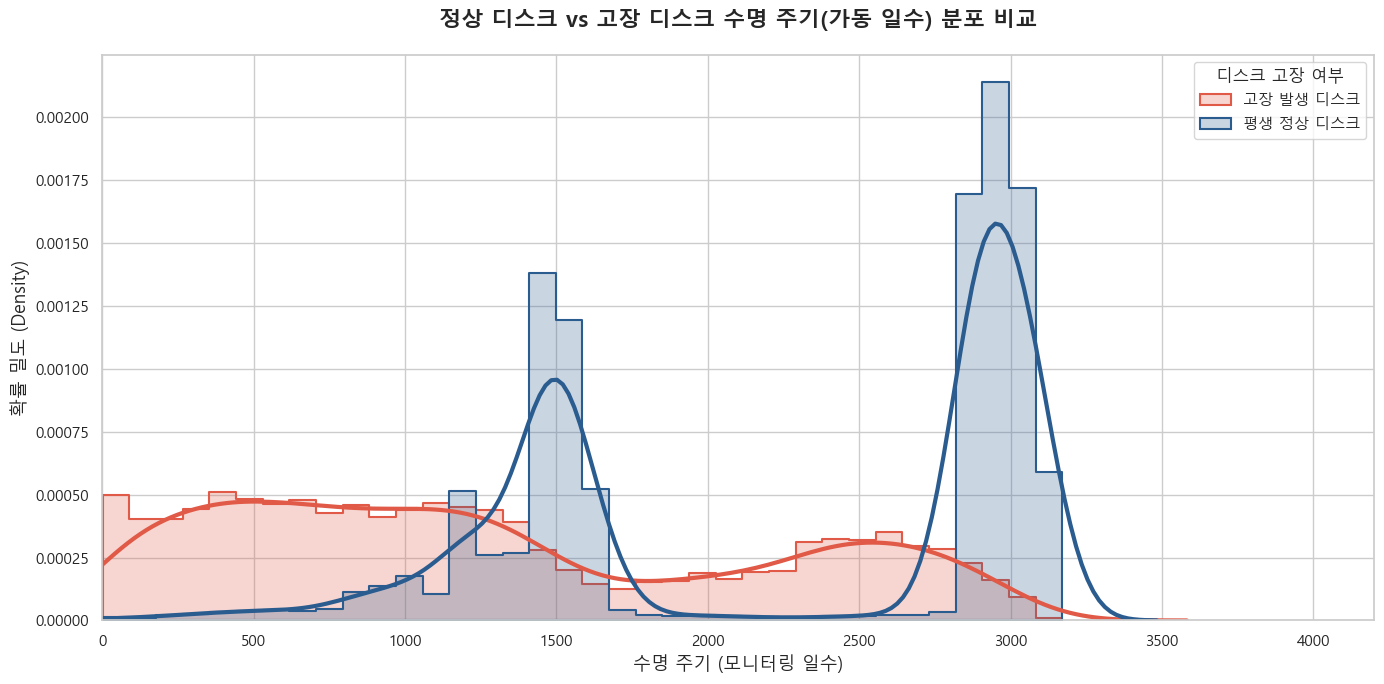

In [6]:
plt.figure(figsize=(14, 7))

# Histogram Overlay
sns.histplot(
    data=lifecycle_df, 
    x="lifecycle_days", 
    hue="is_failed", 
    element="step", 
    stat="density", 
    common_norm=False, 
    palette={0: PRIMARY_COLOR, 1: ACCENT_COLOR},
    alpha=0.25,
    linewidth=1.5
)

# KDE Plot
sns.kdeplot(
    data=lifecycle_df, 
    x="lifecycle_days", 
    hue="is_failed", 
    common_norm=False, 
    palette={0: PRIMARY_COLOR, 1: ACCENT_COLOR},
    linewidth=3,
    legend=False
)

plt.title("정상 디스크 vs 고장 디스크 수명 주기(가동 일수) 분포 비교", fontsize=16, weight="bold", pad=20)
plt.xlabel("수명 주기 (모니터링 일수)", fontsize=13)
plt.ylabel("확률 밀도 (Density)", fontsize=13)
plt.legend(title="디스크 고장 여부", labels=["고장 발생 디스크", "평생 정상 디스크"], fontsize=11, title_fontsize=12)
plt.xlim(0, 4200)
plt.tight_layout()
plt.show()

## 4. 시계열 공백과 청크 분할 분석 (Timeline Gaps & Chunking Analysis)

디스크 데이터 수집 중 시스템 셧다운, 네트워크 오프라인 등으로 **2일 이상의 기록 누락(날짜 Gap >= 3일)**이 발생하면, 2단계 정제에서 해당 물리 디스크는 각각 독립적인 시계열 청크(`new_serial = serial_number_1, _2` 등)로 쪼개졌습니다.

- **가설**: 가동 기간이 매우 긴 정상 디스크일수록 누락 공백이 발생하여 다수의 청크로 쪼개질 확률이 높을 것입니다.
- 개체별 청크 분할 개수의 분포와 정상/고장군 간의 차이를 정밀히 분석합니다.

In [7]:
print("🚀 물리 디스크당 청크 분할 횟수 산출 중...")

chunk_query = f"""
    WITH ChunksPerBase AS (
        SELECT 
            regexp_replace(serial_number, '_[0-9]+$', '') as base_serial,
            CAST(MAX(failure) AS BIGINT) as is_failed,
            COUNT(DISTINCT serial_number) as num_chunks
        FROM read_parquet('{parquet_path}')
        GROUP BY 1
    )
    SELECT 
        is_failed,
        num_chunks,
        COUNT(*) as base_serial_count
    FROM ChunksPerBase
    GROUP BY is_failed, num_chunks
    ORDER BY is_failed DESC, num_chunks ASC
"""
chunk_df = con.execute(chunk_query).df()

# 피벗 테이블 가공
chunk_pivot = chunk_df.pivot(index='num_chunks', columns='is_failed', values='base_serial_count').fillna(0).astype(int)
chunk_pivot.columns = ['정상 디스크', '고장 디스크']

# 백분율 환산
chunk_pct = chunk_pivot.copy()
chunk_pct['정상 디스크 (%)'] = (chunk_pct['정상 디스크'] / chunk_pct['정상 디스크'].sum() * 100).round(2)
chunk_pct['고장 디스크 (%)'] = (chunk_pct['고장 디스크'] / chunk_pct['고장 디스크'].sum() * 100).round(2)

print("\n--- [디스크당 청크 분할 개수별 디스크 수 분포] ---")
print(chunk_pct[['정상 디스크', '정상 디스크 (%)', '고장 디스크', '고장 디스크 (%)']])

# 평균 청크 수 계산
mean_chunks = con.execute(f"""
    WITH ChunksPerBase AS (
        SELECT 
            regexp_replace(serial_number, '_[0-9]+$', '') as base_serial,
            CAST(MAX(failure) AS BIGINT) as is_failed,
            COUNT(DISTINCT serial_number) as num_chunks
        FROM read_parquet('{parquet_path}')
        GROUP BY 1
    )
    SELECT is_failed, AVG(num_chunks) FROM ChunksPerBase GROUP BY is_failed
""").fetchall()
print(f"\n💡 정상 디스크 평균 청크 분할 수: {mean_chunks[1][1]:.3f}개")
print(f"💡 고장 디스크 평균 청크 분할 수: {mean_chunks[0][1]:.3f}개")

🚀 물리 디스크당 청크 분할 횟수 산출 중...



--- [디스크당 청크 분할 개수별 디스크 수 분포] ---
            정상 디스크  정상 디스크 (%)  고장 디스크  고장 디스크 (%)
num_chunks                                        
1              421        1.35    1506       26.42
2            20626       66.05    2819       49.45
3             9715       31.11    1319       23.14
4              376        1.20      49        0.86
5               47        0.15       8        0.14
6                4        0.01       0        0.00
7               38        0.12       0        0.00
8                3        0.01       0        0.00



💡 정상 디스크 평균 청크 분할 수: 1.989개
💡 고장 디스크 평균 청크 분할 수: 2.333개


### 시각화: 정상 디스크 vs 고장 디스크 청크 분할 개수 분포 비교

- **정상 디스크**: 단 한 번의 공백도 없이(청크=1) 가동된 디스크는 **1.35%**에 불과하며, 대다수인 **66.05%가 2개, 31.11%가 3개**의 시계열 청크로 쪼개져 있습니다.
- **고장 디스크**: 상대적으로 수명이 짧기 때문에 공백 발생 확률도 다소 낮아 **26.42%**가 단일 청크로 유지되었으며, **49.45%가 2개, 23.14%가 3개** 청크로 구성되어 있습니다.
- **모델링 핵심 시사점**: 데이터 분할 시 단순 `serial_number`(청크)를 기준으로 삼으면, **동일 물리 디스크에서 쪼개진 청크 `S3000FZ5_1`은 Train 셋에, `S3000FZ5_2`는 Test 셋에 배정되는 심각한 개체 누수(Data Leakage)**가 야기됩니다. 반드시 분할 기준(Group ID)은 오리지널 `base_serial`로 설정해야 합니다.

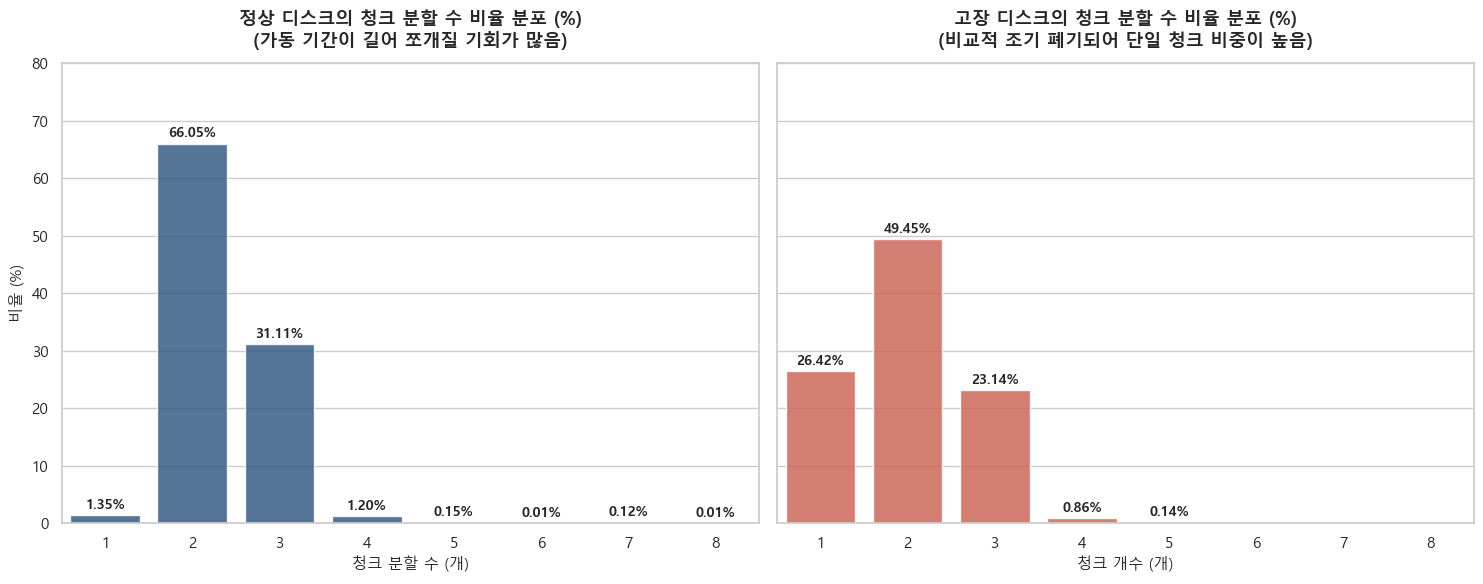

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# 정상 디스크
sns.barplot(x=chunk_pct.index, y="정상 디스크 (%)", data=chunk_pct, ax=axes[0], color=PRIMARY_COLOR, alpha=0.85)
axes[0].set_title("정상 디스크의 청크 분할 수 비율 분포 (%)\n(가동 기간이 길어 쪼개질 기회가 많음)", fontsize=13, weight="bold", pad=12)
axes[0].set_xlabel("청크 분할 수 (개)", fontsize=11)
axes[0].set_ylabel("비율 (%)", fontsize=11)

# 막대 위에 값 레이블링
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f"{height:.2f}%", (p.get_x() + p.get_width() / 2., height + 1),
                    ha='center', va='center', xytext=(0, 3), textcoords='offset points', fontsize=10, weight='bold')

# 고장 디스크
sns.barplot(x=chunk_pct.index, y="고장 디스크 (%)", data=chunk_pct, ax=axes[1], color=ACCENT_COLOR, alpha=0.85)
axes[1].set_title("고장 디스크의 청크 분할 수 비율 분포 (%)\n(비교적 조기 폐기되어 단일 청크 비중이 높음)", fontsize=13, weight="bold", pad=12)
axes[1].set_xlabel("청크 개수 (개)", fontsize=11)
axes[1].set_ylabel("")

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f"{height:.2f}%", (p.get_x() + p.get_width() / 2., height + 1),
                    ha='center', va='center', xytext=(0, 3), textcoords='offset points', fontsize=10, weight='bold')

plt.ylim(0, 80)
plt.tight_layout()
plt.show()

## 5. 고장 라벨 일수 분포와 좌측 절단(Left Censoring) 효과

이론상 고장 디스크(`base_serial`)는 고장 시점 직전 30일(D-30 ~ D-0)인 총 **31일** 동안 고장 라벨(`failure=1`)을 가져야 합니다.
그러나 실제 데이터셋 상에서 집계해보면 31일보다 적은 고장 라벨 일수를 가지는 개체들이 존재합니다. 

**원인 분석**:
1. **조기 고장 개체**: 디스크 투입 직후(모니터링 시작) 30일 이내에 조기 사망하여 관측 시계열 자체가 31일 미만인 경우.
2. **좌측 절단 (Left Censoring)**: 디스크가 전처리 최소 날짜 경계선인 `2014-03-01` 부근에 고장이 나면서, `2014-03-01` 이전의 라벨링 데이터가 필터링 컷오프(Cut-off)된 경우.

In [9]:
# 고장 디스크별 고장 라벨 일수 추출
fail_rows_query = f"""
    WITH BaseFailRows AS (
        SELECT 
            regexp_replace(serial_number, '_[0-9]+$', '') as base_serial,
            SUM(CASE WHEN failure = 1 THEN 1 ELSE 0 END) as num_fail_rows
        FROM read_parquet('{parquet_path}')
        GROUP BY 1
        HAVING MAX(failure) = 1
    )
    SELECT 
        num_fail_rows,
        COUNT(*) as base_serial_count
    FROM BaseFailRows
    GROUP BY num_fail_rows
    ORDER BY num_fail_rows DESC
"""
fail_rows_df = con.execute(fail_rows_query).df()
fail_rows_df['ratio_pct'] = (fail_rows_df['base_serial_count'] / fail_rows_df['base_serial_count'].sum() * 100).round(2)

print("--- [고장 디스크별 failure=1 라벨 행 수 분포 (상위 10개)] ---")
print(fail_rows_df.head(10).to_string(index=False))

# 좌측 절단(Left-Censored) 디스크 사례 탐색 (2014-03-01 필터링 경계 영향)
print("\n--- [좌측 절단(Left-Censored) 디스크 실제 사례 (failure < 31일)] ---")
left_censored = con.execute(f"""
    WITH BaseSerialFailInfo AS (
        SELECT 
            regexp_replace(serial_number, '_[0-9]+$', '') as base_serial,
            MIN(date) as first_date,
            MAX(date) as last_date,
            SUM(CASE WHEN failure = 1 THEN 1 ELSE 0 END) as num_fail_rows
        FROM read_parquet('{parquet_path}')
        GROUP BY 1
        HAVING MAX(failure) = 1
    )
    SELECT 
        base_serial,
        first_date,
        last_date,
        num_fail_rows
    FROM BaseSerialFailInfo
    WHERE num_fail_rows < 31
    ORDER BY last_date ASC
    LIMIT 5
""").df()
print(left_censored.to_string(index=False))

print("\n💡 해석: 위 사례처럼 2014-03-01 부근에 사망한 디스크(예: 2014-03-02 고장)는 2014-03-01 이전 데이터가 삭제되어 단 2일 분량의 고장 라벨만 살아남아 학습에 진입하게 됩니다.")

--- [고장 디스크별 failure=1 라벨 행 수 분포 (상위 10개)] ---
 num_fail_rows  base_serial_count  ratio_pct
          31.0               4996      87.63
          30.0                359       6.30
          29.0                 90       1.58
          28.0                 25       0.44
          27.0                 88       1.54
          26.0                 16       0.28
          25.0                  6       0.11
          24.0                  8       0.14
          23.0                  5       0.09
          22.0                  4       0.07

--- [좌측 절단(Left-Censored) 디스크 실제 사례 (failure < 31일)] ---
base_serial first_date  last_date  num_fail_rows
   W3004ZG5 2014-03-01 2014-03-03            3.0
   W300SZ1R 2014-03-01 2014-03-05            5.0
   Z300NKMB 2014-03-01 2014-03-06            4.0
   Z300WH6N 2014-03-01 2014-03-06            6.0
   W300T2MV 2014-03-01 2014-03-07            7.0

💡 해석: 위 사례처럼 2014-03-01 부근에 사망한 디스크(예: 2014-03-02 고장)는 2014-03-01 이전 데이터가 삭제되어 단 2일 분량의 고장 라벨만 살아남아 학습에 진

## 6. 시간 경과에 따른 디스크 가동 규모 추이 (Temporal Cohort Trends)

전체 수집 연도(2014년~2025년) 동안 매월 가동되고 있는 물리 디스크의 규모 추이를 파악하여, 분석 시기별 기기 집단의 질적 균일성을 검토합니다.

🚀 월별 활성 디스크 개수 집계 연산 중...


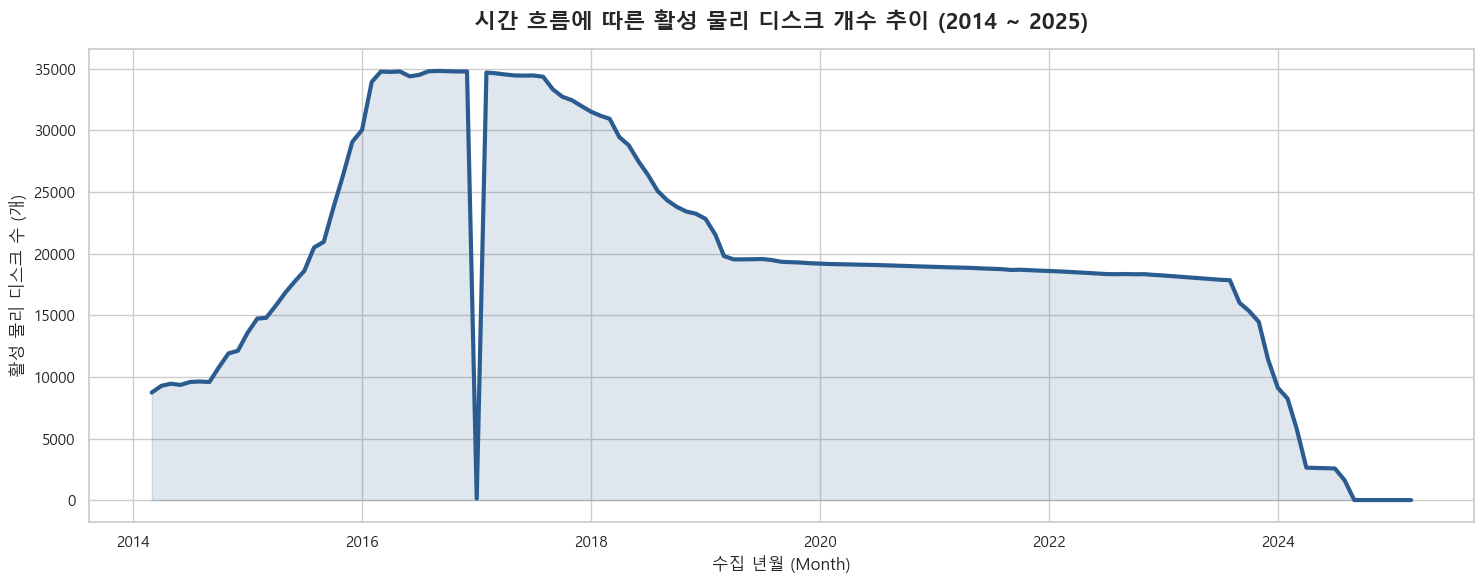

In [10]:
print("🚀 월별 활성 디스크 개수 집계 연산 중...")

temporal_query = f"""
    SELECT 
        date_trunc('month', date)::DATE as active_month,
        COUNT(DISTINCT regexp_replace(serial_number, '_[0-9]+$', '')) as active_disks
    FROM read_parquet('{parquet_path}')
    GROUP BY 1
    ORDER BY 1
"""
temporal_df = con.execute(temporal_query).df()

plt.figure(figsize=(15, 6))
plt.plot(temporal_df['active_month'], temporal_df['active_disks'], color=PRIMARY_COLOR, linewidth=3)
plt.fill_between(temporal_df['active_month'], temporal_df['active_disks'], color=PRIMARY_COLOR, alpha=0.15)

plt.title("시간 흐름에 따른 활성 물리 디스크 개수 추이 (2014 ~ 2025)", fontsize=16, weight="bold", pad=15)
plt.xlabel("수집 년월 (Month)", fontsize=12)
plt.ylabel("활성 물리 디스크 수 (개)", fontsize=12)
plt.tight_layout()
plt.show()

## 7. 머신러닝 모델링 및 평가를 위한 통계적 의사결정 제언

본 분석을 바탕으로, Seagate ST4000DM000 디스크 고장 예측 모델의 학습 및 검증 시 적용해야 할 전문적인 머신러닝 전략을 제언합니다.

### 1️⃣ 개체 단위 데이터 누수 방지 (Mandatory Group Split)
- **현상**: 정상 물리 디스크의 98% 이상, 고장 물리 디스크의 73% 이상이 2개 이상의 청크(`_1`, `_2` 등)로 쪼개져 가동되었습니다.
- **조치**: Train/Val/Test 셋 분할 시 시각적으로 독립되어 보이는 `serial_number`를 분할 기준으로 삼으면 동일 장비의 전후 시점 데이터가 분할 셋에 섞여 들어가는 **개체 누수(Data Leakage)**가 100% 발생합니다. 반드시 `regexp_replace(serial_number, '_[0-9]+$', '')`로 변환한 **`base_serial`을 Group key로 지정**하여 데이터셋 분할(`GroupKFold`, `GroupShuffleSplit`)을 실행해야 신뢰할 수 있는 검증이 가능합니다.

### 2️⃣ 극단적인 클래스 불균요 (Row: 0.22% vs Disk: 15.4%) 대응
- **다운샘플링(Downsampling)**: 정상 디스크의 시계열은 2,000일이 넘을 정도로 지나치게 길어, 이를 모두 학습에 쓰면 다수 클래스 편향이 극대화됩니다. 따라서 정상 디스크의 정상 기간(혹은 고장 디스크의 정상 기간)을 물리 개체 단위로 대표적인 시점만 무작위 또는 윈도우 방식으로 **다운샘플링**하여 학습 셋의 Imbalance Ratio를 최소 5%~10% 수준으로 조정하는 것이 효과적입니다.
- **비용 민감 학습(Cost-Sensitive Learning)**: 로스 함수(Loss Function) 계산 시 `failure=1`인 minority 관측치 행에 대해 400배 이상의 가중치를 부가하거나, Focal Loss 등을 차용하여 모델이 고장 징후 패턴을 포착하도록 강제해야 합니다.

### 3️⃣ 평가 지표(Evaluation Metrics)의 정의
- **행 단위 평가 지향 금지**: 일반적인 분류 지표인 F1-Score, Precision, Recall을 'Row' 기준으로만 계산하면 현업 관제 오탐 폭발(False Alarm Explosion)을 평가할 수 없습니다.
- **디스크 개체 단위 평가**: '특정 디스크가 고장나기 전 30일 이내에 단 한 번이라도 알람(Model Prediction = 1)을 주었는가?'를 기준으로 개체 단위의 Recall(민감도)을 측정하고, 오탐(False Alarm Rate, FAR) 역시 정상 가동 중인 디스크에서 발생한 알람 일수를 기준으로 일별 FAR(예: FAR <= 0.1%)을 제한하는 식의 **개체 중심 평가 정책**이 구현되어야 합니다.

In [11]:
con.close()
print("✅ DuckDB 연결 해제 완료. 분석용 노트북 작성이 완료되었습니다.")

✅ DuckDB 연결 해제 완료. 분석용 노트북 작성이 완료되었습니다.
